# 第 12 章 · 经典手写数字 GAN 代码实验

本页用经典手写数字数据训练一个小型生成对抗网络。读者同时看真实数字、生成数字、判别器分数和损失曲线。

[章节网页](../ch12.html)

## 运行内容

- 加载经典手写数字
- 训练生成器和判别器
- 绘制生成数字

## 0. 数字生成

判别器学习区分真实数字和生成数字，生成器学习骗过判别器。这里固定生成数字 8，让读者更容易判断生成质量；完整 GAN 可以扩展到多个类别。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 安装并导入 GAN 需要的公开库。
gan_packages = {"torch": "torch>=2.2"}
missing = [package for module, package in gan_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import torch
from torch import nn

In [3]:
# 经典手写数字 GAN：只学习数字 8，让生成结果更容易判断。
torch.manual_seed(7)
torch.set_num_threads(1)
digits = load_digits()
target_digit = 8
real_digit_np = digits.images[digits.target == target_digit].astype("float32") / 16.0
real_digits = torch.tensor(real_digit_np.reshape(len(real_digit_np), -1) * 2 - 1, dtype=torch.float32)

latent_dim = 16
image_dim = real_digits.shape[1]
batch_size = 64

generator = nn.Sequential(
    nn.Linear(latent_dim, 64),
    nn.LeakyReLU(0.2),
    nn.Linear(64, 128),
    nn.LeakyReLU(0.2),
    nn.Linear(128, image_dim),
    nn.Tanh(),
)
discriminator = nn.Sequential(
    nn.Linear(image_dim, 128),
    nn.LeakyReLU(0.2),
    nn.Linear(128, 64),
    nn.LeakyReLU(0.2),
    nn.Linear(64, 1),
)
loss_fn = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=0.0012, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0012, betas=(0.5, 0.999))
gan_rows = []

for step in range(1, 1201):
    idx = torch.randint(0, len(real_digits), (batch_size,))
    real_batch = real_digits[idx]
    z = torch.randn(batch_size, latent_dim)
    fake_batch = generator(z).detach()

    real_logits = discriminator(real_batch)
    fake_logits = discriminator(fake_batch)
    d_loss = loss_fn(real_logits, torch.ones_like(real_logits)) + loss_fn(fake_logits, torch.zeros_like(fake_logits))
    opt_d.zero_grad()
    d_loss.backward()
    opt_d.step()

    z = torch.randn(batch_size, latent_dim)
    generated = generator(z)
    g_logits = discriminator(generated)
    g_loss = loss_fn(g_logits, torch.ones_like(g_logits))
    opt_g.zero_grad()
    g_loss.backward()
    opt_g.step()

    if step % 150 == 0:
        with torch.no_grad():
            gan_rows.append({
                "训练步": step,
                "判别器损失": float(d_loss),
                "生成器损失": float(g_loss),
                "真实样本评分": float(torch.sigmoid(discriminator(real_batch)).mean()),
                "生成样本评分": float(torch.sigmoid(discriminator(generator(torch.randn(batch_size, latent_dim)))).mean()),
            })

with torch.no_grad():
    z_fixed = torch.randn(16, latent_dim)
    gan_samples = generator(z_fixed).reshape(16, 8, 8).numpy()
gan_trace = pd.DataFrame(gan_rows)
display(pd.DataFrame({
    "数据集": ["sklearn digits"],
    "目标数字": [target_digit],
    "真实样本数": [len(real_digits)],
    "图像尺寸": ["8x8"],
    "生成向量维度": [image_dim],
}))
display(gan_trace.round(3))

,数据集,目标数字,真实样本数,图像尺寸,生成向量维度
0,sklearn digits,8,174,8x8,64


,训练步,判别器损失,生成器损失,真实样本评分,生成样本评分
0,150,0.947,1.417,0.641,0.362
1,300,0.969,1.673,0.569,0.326
2,450,1.055,1.088,0.663,0.455
3,600,0.832,1.432,0.656,0.293
4,750,1.202,1.052,0.559,0.421
5,900,1.263,0.869,0.569,0.442
6,1050,1.379,1.057,0.471,0.378
7,1200,1.284,1.249,0.480,0.312


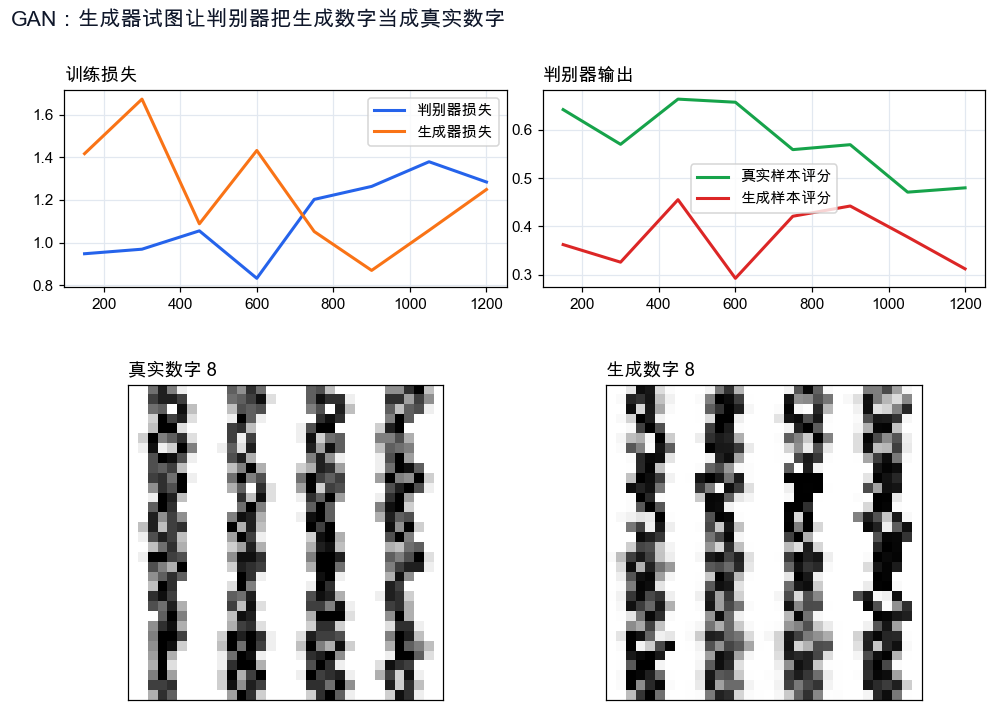

In [4]:
# 绘制训练曲线、真实数字和生成数字。
fig = plt.figure(figsize=(10.8, 7.2))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.6], hspace=0.38, wspace=0.18)
ax_loss = fig.add_subplot(gs[0, :2])
ax_score = fig.add_subplot(gs[0, 2:])
ax_loss.plot(gan_trace["训练步"], gan_trace["判别器损失"], color="#2563eb", linewidth=2.0, label="判别器损失")
ax_loss.plot(gan_trace["训练步"], gan_trace["生成器损失"], color="#f97316", linewidth=2.0, label="生成器损失")
ax_loss.set_title("训练损失", loc="left", fontweight="bold")
ax_loss.grid(True, color="#e2e8f0", linewidth=0.8)
ax_loss.legend()

ax_score.plot(gan_trace["训练步"], gan_trace["真实样本评分"], color="#16a34a", linewidth=2.0, label="真实样本评分")
ax_score.plot(gan_trace["训练步"], gan_trace["生成样本评分"], color="#dc2626", linewidth=2.0, label="生成样本评分")
ax_score.set_title("判别器输出", loc="left", fontweight="bold")
ax_score.grid(True, color="#e2e8f0", linewidth=0.8)
ax_score.legend()

def digit_tile(images, grid=4):
    rows = [
        np.concatenate([images[i * grid + j] for j in range(grid)], axis=1)
        for i in range(grid)
    ]
    return np.concatenate(rows, axis=0)

real_tile = digit_tile(real_digit_np[:16])
fake_tile = digit_tile(((gan_samples[:16] + 1) / 2).clip(0, 1))
ax_real = fig.add_subplot(gs[1, :2])
ax_fake = fig.add_subplot(gs[1, 2:])
ax_real.imshow(real_tile, cmap="gray_r", interpolation="nearest")
ax_real.set_title("真实数字 8", loc="left", fontweight="bold")
ax_fake.imshow(fake_tile, cmap="gray_r", interpolation="nearest")
ax_fake.set_title("生成数字 8", loc="left", fontweight="bold")
for ax in (ax_real, ax_fake):
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("GAN：生成器试图让判别器把生成数字当成真实数字", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()